# Дообучение модели на задаче классификации ДНК-последовательностей при помощи LoRA с контрастивным обучением.

## Импорт и загрузка библиотек

In [1]:
!pip install --upgrade torch
!pip install --upgrade transformers
!pip install peft
!pip install datasets

In [2]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer, DataCollatorWithPadding
from peft import get_peft_model, LoraConfig, TaskType
from datasets import load_dataset
from sklearn.metrics import f1_score, matthews_corrcoef, accuracy_score
import numpy as np
from typing import List

from sklearn.model_selection import train_test_split
from datasets import Dataset

from datasets import load_dataset, Dataset as HFDataset
import random
import torch.nn.functional as F
import warnings

# Скрыть предупреждение
warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

2025-05-01 12:39:18.197132: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746103158.383333      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746103158.438432      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Определение основных параметров

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")


###### Параметры ######
model_name = "InstaDeepAI/nucleotide-transformer-v2-500m-multi-species" # путь к предобученной модели
dataset_name = "H4"  # Название датасета
metric_name = "mcc"  # F1 для promoter_all, MCC для enhancers/H3/H4, Accuracy для splice_sites_all

test_size = 0.1 # коэффициент разделение данных (test_size / dataset_size)
random_state = 42

###### Параметры моделей ######
num_labels = 2  # Количество классов для обучения
r = 8          # Ранг низкоранговой аппроксимации (LoRA) (лучше 16)
lora_alpha = 8 # Масштабирующий коэффициент (LoRA) (лучше 16)
target_modules = ["query", "key", "value"] # Модули внимания (LoRA)
lora_dropout = 0.1                         # Коэффициент регуляризации (LoRA)
bias = 'none'                              # Сдвиг (LoRA)
task_type = TaskType.SEQ_CLS               # Тип задачи: классификация (LoRA)

max_length = 128 # Максимальная длина последовательности для токенизации исходных последовательностей ДНК (лучше 512)

mutation_rate = 0.01     # Вероятность мутирования нуклеотида (contrastive loss)
temperature = 0.5        # Параметр масштабирования (contrastive loss)
max_length_augment = 128 # Максимальная длина последовательности для токенизации аугментированных последовательностей ДНК (contrastive loss) (лучше 512)
lambda_contrastive = 0.1 # Вес влияния contrastive loss на общую функцию потерь (contrastive loss)

num_proc = 4 # Количество процессоров для параллельной работы

device: cuda


## Загрузка данных

Загрузим датасеты с помощью метода `load_dataset` из библиотеки `datasets` от Hugging Face. Далее разделим `train_dataset` на обучающий и валидационный наборы.

Во время выполнения кода ниже потребуется подтвердить загрузку датасета. Просто введите в консоли и подтвердите: `y`

In [ ]:
train_dataset = load_dataset(
    "InstaDeepAI/nucleotide_transformer_downstream_tasks",
    dataset_name,
    split="train",
    streaming=False,
)
test_dataset = load_dataset(
    "InstaDeepAI/nucleotide_transformer_downstream_tasks",
    dataset_name,
    split="test",
    streaming=False,
)

train_indices, valid_indices = train_test_split(
    range(len(train_dataset)), test_size=test_size, stratify=train_dataset["label"], random_state=random_state
)

valid_dataset = train_dataset.select(valid_indices)
train_dataset = train_dataset.select(train_indices)

print("Размер валидационной выборки:", len(valid_dataset))
print("Размер обучающей выборки:", len(train_dataset))

README.md:   0%|          | 0.00/6.40k [00:00<?, ?B/s]

(…)cleotide_transformer_downstream_tasks.py:   0%|          | 0.00/5.97k [00:00<?, ?B/s]

The repository for InstaDeepAI/nucleotide_transformer_downstream_tasks contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/InstaDeepAI/nucleotide_transformer_downstream_tasks.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N]  y


train.fna:   0%|          | 0.00/6.87M [00:00<?, ?B/s]

test.fna:   0%|          | 0.00/763k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

 
                       
        during the per-review process. This version is deprecated and the new datasets are available at 
        InstaDeepAI/nucleotide_transformer_downstream_tasks_revised.
                       
              


Generating test split: 0 examples [00:00, ? examples/s]

 
                       
        during the per-review process. This version is deprecated and the new datasets are available at 
        InstaDeepAI/nucleotide_transformer_downstream_tasks_revised.
                       
              


Размер валидационной выборки: 66
Размер обучающей выборки: 591


## Загрузка модели и токенизатора

Настройка параметров моделей. Поскольку обучение модели требует больших ресурсов, воспользуемся техникой **LoRA**. Она позволяет замораживать основную матрицу весов и обучаться модели на дополнительных матрицах с весами с меньшим рангом (`r`), которые будут корректировать определенные слои исходной матрицы весов (в нашем случае это слои, указанные `target_modules`). То есть тем самым мы адаптируем модель к новой задаче, обучая ее только на части параметров.

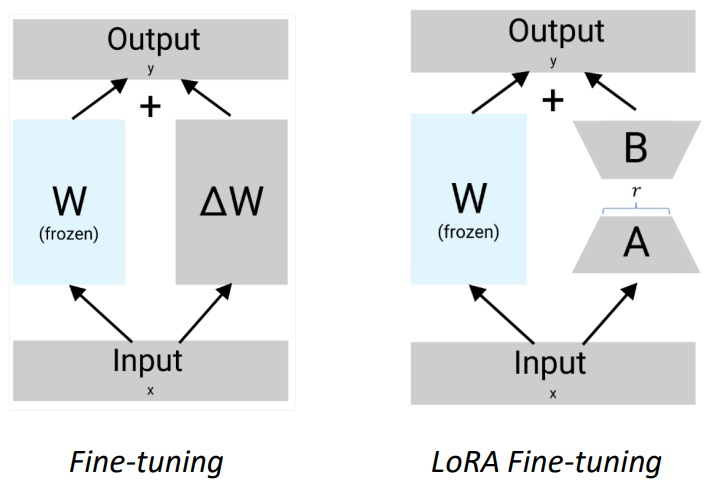


### Основные Параметры:
 - **r**: Ранг матриц LoRA (чем выше, тем больше выразительность, но больше параметров)

 - **lora_alpha**: Коэффициент масштабирования для LoRA-матриц

 - **target_modules**: Список слоев, которые будут корректироваться

 - **lora_dropout**: Вероятность dropout

 - **bias**: Смещения в LoRA-матрицах

 - **task_type**: Тип задачи

### Полезные ссылки:
 - **PEFT**: [эффективные методы дообучения моделей](https://huggingface.co/docs/peft/index)

In [5]:
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=num_labels, trust_remote_code=True
).to(device)

# Настройка LoRA
lora_config = LoraConfig(
    r=r,
    lora_alpha=lora_alpha,
    target_modules=target_modules,
    lora_dropout=lora_dropout,
    bias=bias,
    task_type=task_type
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

tokenizer_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/28.7k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/101 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

esm_config.py:   0%|          | 0.00/14.9k [00:00<?, ?B/s]

...

modeling_esm.py:   0%|          | 0.00/58.2k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/InstaDeepAI/nucleotide-transformer-v2-500m-multi-species:
- modeling_esm.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/1.99G [00:00<?, ?B/s]

Some weights of the model checkpoint at InstaDeepAI/nucleotide-transformer-v2-500m-multi-species were not used when initializing EsmForSequenceClassification: ['lm_head.bias', 'lm_head.decoder.weight', 'lm_head.dense.bias', 'lm_head.dense.weight', 'lm_head.layer_norm.bias', 'lm_head.layer_norm.weight']
- This IS expected if you are initializing EsmForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing EsmForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of EsmForSequenceClassification were not initialized from the model checkpoint at InstaDeepAI/nucleotide-transformer-v2-500m-multi-species and are newly initialized: ['classifier.dense.bias', 

trainable params: 2,477,058 || all params: 496,612,821 || trainable%: 0.4988


## Определение основных функций и классов

### Токенизация

Эффективный процесс токенизации с применением `num_proc` количества процессоров для выполнения операции батчами. Модель **nucleotide transformer** токенизирует последовательности **k-mer = 6**.

In [6]:
def tokenize_function(examples: List) -> List:

    """
    Токенизация списка последовательностей нуклеотидов.
    
    Args:
        examples: Список последовательностей
    Returns:
        Список токенизированных последовательностей ДНК.
    """
    
    return tokenizer(
        examples["sequence"],
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )

train_dataset = train_dataset.map(tokenize_function, batched=True, num_proc=num_proc)
valid_dataset = valid_dataset.map(tokenize_function, batched=True, num_proc=num_proc)

train_dataset = train_dataset.remove_columns(["sequence"])
valid_dataset = valid_dataset.remove_columns(["sequence"])
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
valid_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map (num_proc=4):   0%|          | 0/591 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/66 [00:00<?, ? examples/s]

### Подсчет метрик

In [7]:
def compute_metrics(eval_pred):
    """
    Вычисление метрик.
    
    Args:
        eval_pred: (logits, labels)
    Returns:
        Словарь с метрикой.
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    if metric_name == "f1":
        return {"f1": f1_score(labels, predictions, average="binary")}
    elif metric_name == "mcc":
        return {"mcc": matthews_corrcoef(labels, predictions)}
    elif metric_name == "accuracy":
        return {"accuracy": accuracy_score(labels, predictions)}

### Реализация контрастивной функции потерь и контрастивного обучения

#### Примечания к функциям

Функция **nt_xent_loss**:
 - `Labels` создаются так, чтобы каждая оригинальная последовательность соответствовала своей аугментированной версии как положительная пара.

 - Потери минимизируются, чтобы модель училась делать эмбеддинги похожих последовательностей (исходная и аугментация) ближе друг к другу, а непохожих — дальше. Непохожие последовательности - это все другие последовательности в выборке и их аугментации.

 - Меньшие значения гиперпараметра `temperature` делают модель более чувствительной к различиям между парами.



Формула ниже реализует данную процедуру:

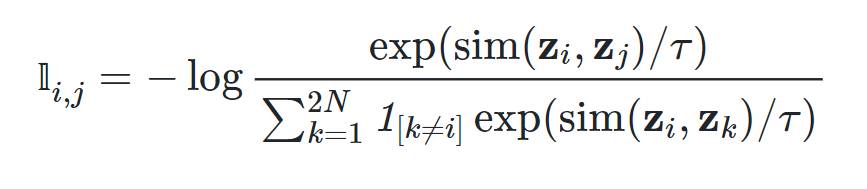

где `zi`, `zj`: эмбеддинги оригинальной и аугментированной последовательностей (положительная пара), `tau` - гиперпараметр `temperature`.


Полезные ссылки:
 - **NT-xent**: [Ссылка на статью от DeepSeek](https://deepseekpro.org/guide/nt-xent-normalized-temperature-scaled-cross-entropy-loss-explained-and-implemented-in-pytorch/)

In [11]:
def augment_sequence(sequence: str, mutation_rate=0.01) -> str:
    """
    Аугментация ДНК-последовательности путём замены равновероятно на другой нуклеотид с вероятностью возникновения процесса mutation_rate.
    
    Args:
        sequence: Входная ДНК-последовательность
        mutation_rate: Вероятность мутирования нуклеотида
        
    Returns:
        Аугментированная последовательность ДНК.
    """
    nucleotides = ['A', 'C', 'G', 'T']
    return ''.join([random.choice(nucleotides) if random.random() < mutation_rate else nuc for nuc in sequence])

def nt_xent_loss(emb1: torch.Tensor, emb2: torch.Tensor, temperature=0.5) -> torch.Tensor:
    """
    Вычисление NT-Xent (Normalized Temperature-scaled Cross Entropy) contrastive loss.
    
    Args:
        emb1: Эмбеддинг исходной (не аугментированной) последовательности
        emb2: Эмбеддинг аугментированной исходной последовательности
        temperature: Параметр масштабирования
        
    Returns:
        Значение констрастивной функции потерь
    """
    batch_size = emb1.size(0)
    emb = torch.cat([emb1, emb2], dim=0)
    sim_matrix = F.cosine_similarity(emb.unsqueeze(1), emb.unsqueeze(0), dim=2) / temperature
    labels = torch.arange(batch_size).to(emb1.device)
    labels = torch.cat([labels + batch_size, labels], dim=0)
    loss = F.cross_entropy(sim_matrix, labels)
    return loss

# Кастомный Trainer
class ContrastiveTrainer(Trainer):
    def __init__(self, *args, processing_class=None, mutation_rate=0.01, temperature=0.5, max_length=512, lambda_contrastive = 0.1, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        self.processing_class = processing_class # Токенизатор
        self.mutation_rate = mutation_rate # Вероятность мутирования нуклеотида
        self.temperature = temperature
        self.max_length = max_length

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs) -> torch.Tensor:
        """
        Вычисление комбинированной функции потерь: BinaryCrossEntropy + lambda_contrastive * Contrastive loss.

        На этапе обучения модели вычисляется комбинированная функция потерь, а во время проверки качества - только бинарная кросс-энтропия.
        
        Args:
            model: предобученная модель с LoRA
            inputs: Входной батч (Input)
            return_outputs: возвращать ли выход после model
        Returns:
            loss или (loss, outputs) - зависит от return_outputs
        """
        
        labels = inputs.pop("labels")
        labels = labels.squeeze()
        if labels.dim() > 1:
            labels = labels.view(-1)
        
        outputs = model(**inputs, output_hidden_states=model.training)
        logits = outputs.logits

        # Вычисление бинарной кросс-энтропии
        classification_loss = F.cross_entropy(logits, labels)
        
        if model.training: # Этап обучения модели
            # Декодирование input_ids обратно в последовательности ДНК
            sequences = [self.processing_class.decode(ids, skip_special_tokens=True) for ids in inputs["input_ids"]]
            
            # Применение аугментации с помощью augment_sequence
            aug_sequences = [augment_sequence(seq, self.mutation_rate) for seq in sequences]

            # Токенизация аугментированной последовательности
            aug_tokens = self.processing_class(
                aug_sequences, padding="max_length", truncation=True, max_length=self.max_length, return_tensors="pt"
            ).to(inputs["input_ids"].device)

            # Вычисляются эмбеддинги для оригинальных и аугментированных последовательностей 
            with torch.no_grad():
                aug_outputs = model(**aug_tokens, output_hidden_states=True)
                aug_hidden_states = aug_outputs.hidden_states[-1]

            # Усреднение скрытых состояний последнего слоя
            emb = torch.mean(outputs.hidden_states[-1], dim=1)
            aug_emb = torch.mean(aug_hidden_states, dim=1)

            # Вычисление contrastive loss с помощью nt_xent_loss
            contrastive_loss = nt_xent_loss(emb, aug_emb, temperature=self.temperature)

            # Комбинирование итоговой функции потерь
            loss = (1 - lambda_contrastive) * classification_loss + lambda_contrastive * contrastive_loss
        else: # Этап проверки качества модели

            # Использование только бинарной кросс-энтропии
            loss = classification_loss
        
        torch.cuda.empty_cache()

        return (loss, outputs) if return_outputs else loss

## Настройка параметров обучения

In [17]:
# Настройка обучения
training_args = TrainingArguments(
    output_dir=f"./results_{dataset_name}", # Директория для сохранения модели
    num_train_epochs=10,                     # Количество эпох обучения (лучше 6)
    per_device_train_batch_size=8,          # Размер батча для обучения (лучше 16)
    per_device_eval_batch_size=8,           # Размер батча для валидации (лучше 16)
    warmup_steps=400,                       # Линейное увеличение скорости обучения в течение первых warmup_steps шагов
    weight_decay=0.1,                       # L2-регуляризация (для предотвращения переобучения)
    # learning_rate=2e-5,                    # Шаг обучения
    logging_dir=f"./logs_{dataset_name}",   # Директория для сохранения логов
    logging_steps=1,                        # (лучше 20)
    eval_strategy="steps",                  # Оценка каждые eval_steps шагов.
    eval_steps=2,                           # (лучше 200)
    save_strategy="steps",                  # Сохранение модели каждые save_steps шагов, хранение только save_total_limit последних чекпоинтов.
    save_steps=2,                           # (лучше 200)
    save_total_limit=2,
    load_best_model_at_end=True,            # После обучения загружается модель с лучшей метрикой eval_mcc
    metric_for_best_model=f"eval_{metric_name}", # Метрика оценки качества
    greater_is_better=True,
    fp16=True,                              # Использование смешанной точности для ускорения и экономии памяти
    gradient_accumulation_steps=2,          # (лучше 1, т.к. 16 батчей - оптимальный размер)
    dataloader_num_workers=4,               # Параллельная загрузка данных с dataloader_num_workers потоками.
    max_grad_norm=1.0,                      # Ограничение нормы градиента (Липшицева константа)
    report_to="tensorboard"
)

# Trainer
trainer = ContrastiveTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    processing_class=tokenizer,
    mutation_rate=mutation_rate,
    temperature=temperature, 
    max_length=max_length_augment, 
    lambda_contrastive = lambda_contrastive
)

# Очистка кэша
torch.cuda.empty_cache()

No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


## Обучение

Параметры настройки обучения модели сделаны для более быстрого обучения. **Качество** на таких параметрах **будет низким**.

Если необходимо более качественное обучение, то **лучше подкорректировать параметры** (в комментариях есть рекомендованные значения для каждого параметра). Соответственно, лучше обучать модель на видеокартах A100 или V100.

In [18]:
trainer.train()

Step,Training Loss,Validation Loss,Mcc
2,0.955000,0.695724,-0.096927
4,0.915700,0.695707,-0.096927
6,0.910600,0.695702,-0.096927
8,0.903100,0.695710,-0.138095
10,0.911700,0.695460,-0.138095
12,0.880100,0.695493,-0.138095
14,0.819300,0.695398,-0.138095
16,0.892800,0.695392,-0.138095
18,0.916600,0.695401,-0.138095
20,0.851600,0.695096,-0.096927


TrainOutput(global_step=370, training_loss=0.7781835769479339, metrics={'train_runtime': 892.1454, 'train_samples_per_second': 6.624, 'train_steps_per_second': 0.415, 'total_flos': 2225449415600640.0, 'train_loss': 0.7781835769479339, 'epoch': 10.0})

## Оценка качества

In [19]:
results = trainer.evaluate()
print(f"Results for {dataset_name}: {results}")

Results for H4: {'eval_loss': 0.4954462945461273, 'eval_mcc': 0.6119413561345446, 'eval_runtime': 1.861, 'eval_samples_per_second': 35.464, 'eval_steps_per_second': 4.836, 'epoch': 10.0}


## Сохранение модели и токенизатора

Модель сохраняется с адаптированными LoRA-весами.

In [20]:
model.save_pretrained(f"./finetuned_{dataset_name}")
tokenizer.save_pretrained(f"./finetuned_{dataset_name}")

('./finetuned_H4/tokenizer_config.json',
 './finetuned_H4/special_tokens_map.json',
 './finetuned_H4/vocab.txt',
 './finetuned_H4/added_tokens.json')

## Тестирование модели

### Без подгрузки весов на тестовом наборе с вычислением метрики

In [21]:
test_dataset = load_dataset(
    "InstaDeepAI/nucleotide_transformer_downstream_tasks",
    dataset_name,
    split="test",
    streaming=False,
)

test_dataset = test_dataset.map(tokenize_function, batched=True, num_proc=8)

# Удаление ненужных столбцов и установка формата
test_dataset = test_dataset.remove_columns(["sequence"])

test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
# Предсказание на тестовой выборке
predictions_output = trainer.predict(test_dataset)

# Извлечение предсказаний и метрик
predictions = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids
metrics = predictions_output.metrics

# Вывод результатов
print(f"Test results for {dataset_name}:")
print(f"{metric_name}: {metrics[f'test_{metric_name}']:.4f}")
print(f"Predictions: {predictions[:10]}")  # Первые 10 предсказаний для примера
print(f"True labels: {labels[:10]}")  # Первые 10 истинных меток для примера

Test results for H4:
mcc: 0.4707
Predictions: [1 0 0 0 0 1 0 1 0 0]
True labels: [1 0 0 0 0 1 0 1 1 0]


### Подгрузка весов и предсказание

In [ ]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from peft import PeftModel, PeftConfig

def load_peft_model_and_tokenizer(model_dir, tokenizer_dir, device=None):
    """
    Загружает PEFT-модель и токенизатор
    
    Args:
        model_dir: путь к директории с PEFT-моделью
        tokenizer_dir: путь к директории с токенизатором
        device: устройство для загрузки (cuda/cpu), если None - определит автоматически
        
    Returns:
        model, tokenizer
    """
    # Определяем устройство
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    try:
        # Загружаем конфиг PEFT
        peft_config = PeftConfig.from_pretrained(model_dir)
        
        # Загружаем базовую модель
        base_model = AutoModelForSequenceClassification.from_pretrained(
            peft_config.base_model_name_or_path,
            num_labels=2,
            trust_remote_code=True
        )
        
        # Загружаем PEFT-адаптеры
        model = PeftModel.from_pretrained(
            base_model,
            model_dir,
            trust_remote_code=True
        )
        
        model = model.to(device)
        model.eval()
        
        # Загружаем токенизатор
        tokenizer = AutoTokenizer.from_pretrained(
            tokenizer_dir,
            trust_remote_code=True
        )
        
        print(f"Модель и токенизатор успешно загружены на устройство {device}")
        return model, tokenizer
        
    except Exception as e:
        raise ValueError(f"Ошибка при загрузке модели: {str(e)}")


dir_tokenizer = '/kaggle/working/finetuned_H4'
save_directory = '/kaggle/working/results_H4/checkpoint-222'

model, tokenizer = load_peft_model_and_tokenizer(
    model_dir=save_directory,
    tokenizer_dir=dir_tokenizer
)

In [ ]:
def predict(text, model, tokenizer, device):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.argmax(outputs.logits, dim=-1)
    
    return predictions.cpu().numpy()

# Тестовый пример
text = ["AGCGAATTCGAGCGCGAATTCGCG","CGCGAATTCGCGCGCGAATTCGCGCGCGAATTCGCG", "CGCGAATTCGCG"]
print(f"Предсказание: {predict(text, model, tokenizer, device)}")